# Heterogeneous-Voxel At-Scale τ-p Demo (Oceanic Crust, Riccati Interlayer)

End-to-end demo of the heterogeneous-voxel block Foldy-Lax inner
solver composed with the Riccati interlayer-multiple-scattering outer
sweep, on a realistic 20-layer oceanic-crust model.  Each of the 18
finite elastic layers carries an independent 32 × 32 lattice of
cubic voxels whose material contrasts are drawn from a per-layer
Gaussian mixture (soft + hard component).

Pipeline:

1. Load the YAML config and build the `LayerModel`.
2. Sample per-voxel `MaterialContrast`s per elastic layer.
3. Per-layer inner solve (frequency-batched block GMRES on
   `(I − G · T_per_cube)`) → one composite `(F, 9, 9)` per layer.
4. Per-ω outer Riccati sweep → `R_total(ω, p)` and `R_ref(ω, p)`.
5. Ricker × Hermitian IFFT → total and reference τ-p traces.
6. Display reference and total wiggle gathers + an $|R(\omega,p)|$
   heatmap.
7. Save NPZ + PDFs under `GlobalMatrix/output/taup_scale_demo/`.

**Output-artifact locations** — `GlobalMatrix/output/taup_scale_demo/`
(NPZ, three PDFs).


In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

ms_root = Path("/Users/tod/Desktop/MultipleScatteringCalculations")
if str(ms_root) not in sys.path:
    sys.path.insert(0, str(ms_root))

from GlobalMatrix.taup_scale_demo import (  # noqa: E402
    build_oceanic_crust_model,
    compute_R_omega_p_stack,
    compute_layer_composite_tmatrices_het,
    load_scale_demo_config,
    plot_r_omega_p_heatmap,
    plot_taup_wiggle_gather,
    sample_voxel_contrasts,
    taup_traces_from_R_omega_p,
)

CONFIG_PATH = Path("taup_scale_demo_config.yaml")
# CONFIG_PATH = Path("taup_scale_demo_config_minimal.yaml")
print(f"config: {CONFIG_PATH.resolve()}")

config: /Users/tod/Desktop/SeismicInversion/GlobalMatrix/taup_scale_demo_config.yaml


## 1. Load YAML + Build Layer Model


In [2]:
config = load_scale_demo_config(CONFIG_PATH)

# ---- Minimal-model override: slice to two elastic heterogeneous layers ----
#
# The full oceanic-crust YAML config declares 20 layers (water + 3
# sediments + 3 pillow basalts + 4 dykes + 8 gabbros + mantle
# half-space), which means 18 elastic interfaces that each require an
# independent slowness-coupled block Foldy-Lax solve.  For this demo
# we only need to exercise the inner/outer composition and the
# interlayer-multiple-scattering pipeline — one or two heterogeneous
# layers is enough to show the refactor works end-to-end and to
# generate visually meaningful τ-p gathers.
#
# We keep:
#   - the water column         (layer 0)
#   - pillow basalt (pillow_2) (upper-crust heterogeneous slab)
#   - gabbro_5                 (lower-crust heterogeneous slab)
#   - mantle half-space        (layer 19)
#
# The `voxels.overrides` dict is keyed by the original iface indices
# so we clear it — the remaining two elastic layers will use the
# default Gaussian-mixture parameters (which we replace below).
_orig_layers = config.layers
_idx_water = 0
_idx_pillow = next(
    i for i, layer in enumerate(_orig_layers) if layer.name == "pillow_2"
)
_idx_gabbro = next(
    i for i, layer in enumerate(_orig_layers) if layer.name == "gabbro_5"
)
_idx_mantle = next(i for i, layer in enumerate(_orig_layers) if layer.name == "mantle")
config.layers = [
    _orig_layers[_idx_water],
    _orig_layers[_idx_pillow],
    _orig_layers[_idx_gabbro],
    _orig_layers[_idx_mantle],
]
config.voxels.overrides = {}
# --------------------------------------------------------------------------

# ---- Physically sensible GMM contrasts ----
#
# The YAML defaults (fractional Δλ hard mean = 2.0, soft mean = -1.5)
# are so aggressive that the soft component drives the scatterer
# Lamé parameter λ negative in the basalt/gabbro layers, which is
# unphysical and produces |R_total| ≫ 1.  For a demo of the solver
# composition we want ±10-30% fractional contrasts that keep λ, μ, ρ
# strictly positive and sit comfortably within a perturbative
# multiple-scattering regime.
from GlobalMatrix.taup_scale_demo import GMMParams  # noqa: E402

config.voxels.defaults = GMMParams(
    p_soft=0.3,
    hard_mean=(+0.20, +0.15, +0.05),
    hard_std=(0.05, 0.05, 0.01),
    soft_mean=(-0.20, -0.15, -0.05),
    soft_std=(0.05, 0.05, 0.01),
)
# -------------------------------------------

model = build_oceanic_crust_model(config)

print(f"n_layers   = {config.n_layers}")
print(f"elastic ifaces = {config.elastic_iface_range}")
print(
    f"voxels     = {config.voxels.M}×{config.voxels.M}×{config.voxels.N_z} "
    f"(a = {config.voxels.a_km * 1000:.1f} m)"
)
print(f"n_cubes/layer = {config.voxels.M**2 * config.voxels.N_z}")
print(f"nw         = {config.nw}  (positive frequencies)")
print(f"T_record   = {config.T_record:.1f} s")
print(f"damping    = {config.damping:g} rad/s")
print(f"slowness   = [{config.p_min:.3f}, {config.p_max:.3f}] s/km, n_p={config.n_p}")
print()
print("Layer stack:")
for i, layer in enumerate(config.layers):
    thick_str = (
        "  half-space"
        if not np.isfinite(layer.thickness)
        else f"{layer.thickness:6.3f} km"
    )
    print(
        f"  [{i:2d}] {layer.name:>10s}  α={layer.alpha:4.2f}  β={layer.beta:4.2f}  "
        f"ρ={layer.rho:4.2f}  thick={thick_str}"
    )
print()
print("GMM fractional perturbation defaults (overrides cleared):")
gd = config.voxels.defaults
print(f"  p_soft    = {gd.p_soft}")
print(f"  hard mean = {gd.hard_mean}  std = {gd.hard_std}")
print(f"  soft mean = {gd.soft_mean}  std = {gd.soft_std}")

n_layers   = 4
elastic ifaces = (1, 2)
voxels     = 32×32×1 (a = 10.0 m)
n_cubes/layer = 1024
nw         = 256  (positive frequencies)
T_record   = 32.0 s
damping    = 0.1 rad/s
slowness   = [0.050, 0.600] s/km, n_p=48

Layer stack:
  [ 0]      water  α=1.50  β=0.00  ρ=1.03  thick= 4.500 km
  [ 1]   pillow_2  α=4.00  β=2.20  ρ=2.60  thick= 0.500 km
  [ 2]   gabbro_5  α=6.90  β=3.80  ρ=2.97  thick= 0.400 km
  [ 3]     mantle  α=8.10  β=4.50  ρ=3.30  thick=  half-space

GMM fractional perturbation defaults (overrides cleared):
  p_soft    = 0.3
  hard mean = (0.2, 0.15, 0.05)  std = (0.05, 0.05, 0.01)
  soft mean = (-0.2, -0.15, -0.05)  std = (0.05, 0.05, 0.01)


## 2. Sample Per-Voxel Contrasts

Each of the two retained elastic layers (pillow basalt, gabbro) gets
its own 1024-long list of `MaterialContrast` samples drawn from the
layer's GMM.


In [3]:
rng = np.random.default_rng(config.random_seed)
voxel_contrasts = sample_voxel_contrasts(config, rng)

print(f"elastic ifaces sampled: {sorted(voxel_contrasts.keys())}")
print()
print("per-layer mean Δλ / Δμ / Δρ (realised sample means):")
for iface in sorted(voxel_contrasts.keys()):
    cs = voxel_contrasts[iface]
    dl = np.mean([c.Dlambda for c in cs])
    dm = np.mean([c.Dmu for c in cs])
    dr = np.mean([c.Drho for c in cs])
    layer_name = config.layers[iface].name
    print(
        f"  iface {iface:2d} ({layer_name:>10s}): "
        f"Δλ̄={dl:+.3f}  Δμ̄={dm:+.3f}  Δρ̄={dr:+.3f}"
    )

elastic ifaces sampled: [1, 2]

per-layer mean Δλ / Δμ / Δρ (realised sample means):
  iface  1 (  pillow_2): Δλ̄=+1.237  Δμ̄=+0.737  Δρ̄=+0.051
  iface  2 (  gabbro_5): Δλ̄=+3.982  Δμ̄=+2.253  Δρ̄=+0.052


## 3. Per-Layer Inner Block GMRES (Heterogeneous Foldy-Lax, 2D τ-p mode)

For each elastic layer we run the slowness-batched heterogeneous
block Foldy-Lax solver on the 32×32×1 voxel lattice and accumulate a
composite `(F, n_p, n_p, 9, 9)` tensor that carries plane-wave phase
shifts coupling every `(p_out, p_in)` slowness pair.  The slowness
grid is the **fully 2D fan** built in §3 (`n_p_x × n_p_y` pairs of
`(p_x, p_y)`) so the solver captures horizontal scattering from both
the x and y directions; the central `p_y=0` row recovers the
single-azimuth back-azimuthal cut, while the off-axis rows carry the
side-scattered modes that a strict `ky=0` projection would miss.

Results are persisted to `cache_dir/iface_{j:02d}/freq_{f:04d}.npz`
so a crash or rerun resumes from the last completed frequency.
Layer-parallel multiprocessing (`n_workers=8`) uses independent
workers, each with BLAS clamped to a single thread to prevent
oversubscription.

In [4]:
# ---- Validation-scale override ----
#
# With the model reduced to two elastic heterogeneous layers (pillow
# basalt + gabbro), we only have 2 iface jobs instead of 18, so the
# total inner-solve budget is ~9× cheaper than the full oceanic crust.
# That lets us bump the frequency count back up to a more meaningful
# time resolution.  The per-job cost is still super-linear in `n_p`
# (empirically ~ cubic — the slowness coupling in the (I - G·T)
# matvec introduces an O(n_p²) cost per GMRES iteration and the
# iteration count grows mildly with n_p), so we keep the 2D fan
# modest.
#
#   nw:                  256 → 64         (64 positive frequencies)
#   n_p_x × n_p_y:       —   → 8 × 3 = 24  (coarse 2D fan, p_y=0 centred)
#
# Remove this override block for an at-scale production run.
config.nw = 64
# ------------------------------------

dw = 2.0 * np.pi / config.T_record
omegas_real = np.arange(1, config.nw + 1, dtype=np.float64) * dw
omegas_complex = omegas_real + 1j * config.damping

freqs_hz = omegas_real / (2.0 * np.pi)
print(f"ω grid: {config.nw} positive frequencies")
print(f"  dω = 2π/T = {dw:.4f} rad/s")
print(f"  f range = [{freqs_hz[0]:.3f}, {freqs_hz[-1]:.3f}] Hz")
print(f"  damping = {config.damping:g} rad/s (imag part of ω)")

# 2D horizontal slowness grid for τ-p mode.
#
# The inner Foldy-Lax solver and the outer multi-p Riccati sweep both
# consume a fully 2D slowness grid `slowness_2d` of shape `(n_p, 2)`
# with columns `(p_x, p_y)`.  To include horizontal scattering from
# both the x AND y directions we use a tensor-product fan
# `(n_p_x × n_p_y)` covering an axisymmetric (px, py) wedge centred on
# `p_y = 0`.  The central py-row recovers the back-azimuthal
# single-azimuth τ-p gather; the off-axis rows capture cross-line
# scattering modes that would be missed by a strict ky=0 projection.
n_p_x = 8
n_p_y = 3
p_x_vals = np.linspace(config.p_min, config.p_max, n_p_x)
p_y_vals = np.linspace(-config.p_max, config.p_max, n_p_y)
assert n_p_y % 2 == 1, "n_p_y must be odd so the central row is exactly p_y=0"
PY_zero_idx = n_p_y // 2
assert abs(float(p_y_vals[PY_zero_idx])) < 1e-12, "central row must be p_y=0"

PX, PY = np.meshgrid(p_x_vals, p_y_vals, indexing="ij")  # (n_p_x, n_p_y)
slowness_2d = np.column_stack([PX.ravel(), PY.ravel()])  # (n_p_x*n_p_y, 2)
n_p = slowness_2d.shape[0]

# `p_values` is kept as the 1D x-axis magnitude for the wiggle-gather
# plot helpers (which take a 1D slowness axis).
p_values = p_x_vals

print(f"\nslowness fan: n_p_x={n_p_x} × n_p_y={n_p_y} = {n_p} slownesses")
print(
    f"  p_x ∈ [{config.p_min:.3f}, {config.p_max:.3f}] s/km "
    f"(includes scattering from x direction)"
)
print(
    f"  p_y ∈ [{-config.p_max:.3f}, {config.p_max:.3f}] s/km "
    f"(includes scattering from y direction)"
)
print(f"  central row at index {PY_zero_idx} is the back-azimuthal p_y=0 cut")
print(f"slowness_2d shape = {slowness_2d.shape}")

# Crash-resumable disk cache for per-(iface, freq) composite T-blocks.
cache_dir = project_root / config.output_dir / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)
print(f"cache_dir: {cache_dir}")

ω grid: 64 positive frequencies
  dω = 2π/T = 0.1963 rad/s
  f range = [0.031, 2.000] Hz
  damping = 0.1 rad/s (imag part of ω)

slowness fan: n_p_x=8 × n_p_y=3 = 24 slownesses
  p_x ∈ [0.050, 0.600] s/km (includes scattering from x direction)
  p_y ∈ [-0.600, 0.600] s/km (includes scattering from y direction)
  central row at index 1 is the back-azimuthal p_y=0 cut
slowness_2d shape = (24, 2)
cache_dir: /Users/tod/Desktop/SeismicInversion/GlobalMatrix/output/taup_scale_demo/cache


In [5]:
print("Per-layer heterogeneous block Foldy-Lax solves (τ-p mode)...\n")
# n_workers=8 uses layer-parallel multiprocessing on an M-series / 10-core Mac.
# Each worker clamps BLAS to 1 thread to prevent oversubscription.  Set to
# None or 1 to run sequentially (useful for profiling a single layer).
N_WORKERS = 8

t0 = time.perf_counter()
tmatrices, iters, rel_res = compute_layer_composite_tmatrices_het(
    config=config,
    voxel_contrasts=voxel_contrasts,
    omegas=omegas_complex,
    slowness_2d=slowness_2d,
    cache_dir=cache_dir,
    freq_batch_size=64,
    n_workers=N_WORKERS,
    verbose=True,
)
inner_elapsed = time.perf_counter() - t0

max_res_all = max(float(np.max(r)) for r in rel_res.values())
first_shape = tmatrices[next(iter(tmatrices))].shape
print(f"\ninner solves: {len(tmatrices)} layers, elapsed = {inner_elapsed:.1f} s")
print(f"                n_workers = {N_WORKERS}")
print(f"composite T-matrix shape per layer: {first_shape}")
print(f"max rel residual across all layers × ω = {max_res_all:.2e}")
assert max_res_all < 1e-6, (
    f"Block GMRES did not converge everywhere: max rel res = {max_res_all:.2e}"
)

Per-layer heterogeneous block Foldy-Lax solves (τ-p mode)...

  τ-p mode: 2 ifaces × 64 freqs = 128 jobs (n_p=24 stacked as RHS columns), n_workers=8
  [   1/128] iface  1 f[   1]=0.393rad/s: iters= 8, rel res=1.93e-09 [cached]
  [   2/128] iface  1 f[   0]=0.196rad/s: iters= 8, rel res=2.06e-09 [cached]
  [   3/128] iface  1 f[   3]=0.785rad/s: iters= 8, rel res=2.01e-09 [cached]
  [   4/128] iface  1 f[   2]=0.589rad/s: iters= 8, rel res=1.96e-09 [cached]
  [   5/128] iface  1 f[   4]=0.982rad/s: iters= 8, rel res=2.02e-09 [cached]
  [   6/128] iface  1 f[   5]=1.178rad/s: iters= 8, rel res=2.05e-09 [cached]
  [   7/128] iface  1 f[   6]=1.374rad/s: iters= 8, rel res=2.07e-09 [cached]
  [   8/128] iface  1 f[   7]=1.571rad/s: iters= 8, rel res=2.02e-09 [cached]
  [   9/128] iface  1 f[   8]=1.767rad/s: iters= 8, rel res=1.96e-09 [cached]
  [  10/128] iface  1 f[   9]=1.963rad/s: iters= 8, rel res=1.96e-09 [cached]
  [  11/128] iface  1 f[  10]=2.160rad/s: iters= 8, rel res=2.00e-09 [

## 4. Outer Riccati Interlayer-MS Sweep → R(ω, p)

Per-ω call to `interlayer_ms_reflectivity_9x9_multi_p` on the 20-layer
model with the 18 composite `(n_p, n_p, 9, 9)` T-blocks.  The multi-p
outer solver jointly couples every slowness at every scatterer
interface through the per-interface slowness-coupling block.  Returns
both `R_total` (includes scatterers) and `R_ref` (background
stratified response).

In [6]:
# Each composite T returned by the heterogeneous inner solver is the
# aggregate response of the entire M×M block of cubes (not of a single
# voxel), so the correct areal number density is one block per block
# area = 1 / (M · 2a)².  Equivalently this is the per-cube
# space-filling density 1/(2a)² divided by M² = n_cubes-per-block.
block_edge_km = config.voxels.M * 2.0 * config.voxels.a_km
n_density = 1.0 / block_edge_km**2
print(f"block edge  = {block_edge_km * 1000:.1f} m, area = {block_edge_km**2:.4f} km²")
print(f"n_density   = {n_density:.4f} blocks/km²")

t0 = time.perf_counter()
R_total_wp, R_ref_wp = compute_R_omega_p_stack(
    model=model,
    tmatrices_per_iface=tmatrices,
    omegas=omegas_complex,
    slowness_2d=slowness_2d,
    n_density=n_density,
)
outer_elapsed = time.perf_counter() - t0

print(
    f"outer sweep: {config.nw} frequencies × {n_p} 2D slownesses, "
    f"elapsed = {outer_elapsed:.1f} s"
)
print(f"R_total shape = {R_total_wp.shape}")
print(f"R_ref   shape = {R_ref_wp.shape}")
print(f"max |R_total| = {np.abs(R_total_wp).max():.3f}")
print(f"max |R_ref|   = {np.abs(R_ref_wp).max():.3f}")
assert np.all(np.isfinite(R_total_wp)), "R_total has non-finite entries"
assert np.all(np.isfinite(R_ref_wp)), "R_ref has non-finite entries"

# Reshape (F, n_p) → (F, n_p_x, n_p_y) so we can slice along p_y or
# extract the back-azimuthal p_y=0 cut for the 1D wiggle gathers.
R_total_grid = R_total_wp.reshape(config.nw, n_p_x, n_p_y)
R_ref_grid = R_ref_wp.reshape(config.nw, n_p_x, n_p_y)
R_total_py0 = R_total_grid[:, :, PY_zero_idx]  # (F, n_p_x)
R_ref_py0 = R_ref_grid[:, :, PY_zero_idx]  # (F, n_p_x)

print(f"\nreshape → R_total_grid.shape = {R_total_grid.shape}  (F, n_p_x, n_p_y)")
print(f"py=0 cut → R_total_py0.shape  = {R_total_py0.shape}  (F, n_p_x)")

rel_pert = float(
    np.linalg.norm(R_total_wp - R_ref_wp) / max(np.linalg.norm(R_ref_wp), 1e-30)
)
print(f"relative perturbation ||R_total - R_ref|| / ||R_ref|| = {rel_pert:.3e}")

block edge  = 640.0 m, area = 0.4096 km²
n_density   = 2.4414 blocks/km²
outer sweep: 64 frequencies × 24 2D slownesses, elapsed = 0.9 s
R_total shape = (64, 24)
R_ref   shape = (64, 24)
max |R_total| = 0.942
max |R_ref|   = 0.333

reshape → R_total_grid.shape = (64, 8, 3)  (F, n_p_x, n_p_y)
py=0 cut → R_total_py0.shape  = (64, 8)  (F, n_p_x)
relative perturbation ||R_total - R_ref|| / ||R_ref|| = 6.038e-01


## 5. Ricker × Hermitian IFFT → τ-p Traces


In [7]:
# τ-p traces along the back-azimuthal p_y=0 cut.  The full 2D fan
# enters the inner solver and the multi-p Riccati sweep, but for the
# 1D wiggle gather we slice the central p_y=0 row.
time_axis, traces_total = taup_traces_from_R_omega_p(
    R_omega_p=R_total_py0,
    omegas_real=omegas_real,
    T_record=config.T_record,
)
_, traces_ref = taup_traces_from_R_omega_p(
    R_omega_p=R_ref_py0,
    omegas_real=omegas_real,
    T_record=config.T_record,
)
print(
    f"time axis: {time_axis.shape[0]} samples, "
    f"dt={time_axis[1] - time_axis[0]:.4f} s, "
    f"T={time_axis[-1] + (time_axis[1] - time_axis[0]):.2f} s"
)
print(f"traces_total shape = {traces_total.shape}  (nt, n_p_x)")
print(f"traces_ref   shape = {traces_ref.shape}  (nt, n_p_x)")
print(f"|traces_total| max = {np.abs(traces_total).max():.3e}")
print(f"|traces_ref  | max = {np.abs(traces_ref).max():.3e}")

time axis: 130 samples, dt=0.2462 s, T=32.00 s
traces_total shape = (130, 8)  (nt, n_p_x)
traces_ref   shape = (130, 8)  (nt, n_p_x)
|traces_total| max = 4.053e+00
|traces_ref  | max = 3.808e+00


## 6. Display: Reference + Total Wiggle Gathers, $|R(\omega, p)|$ Heatmap


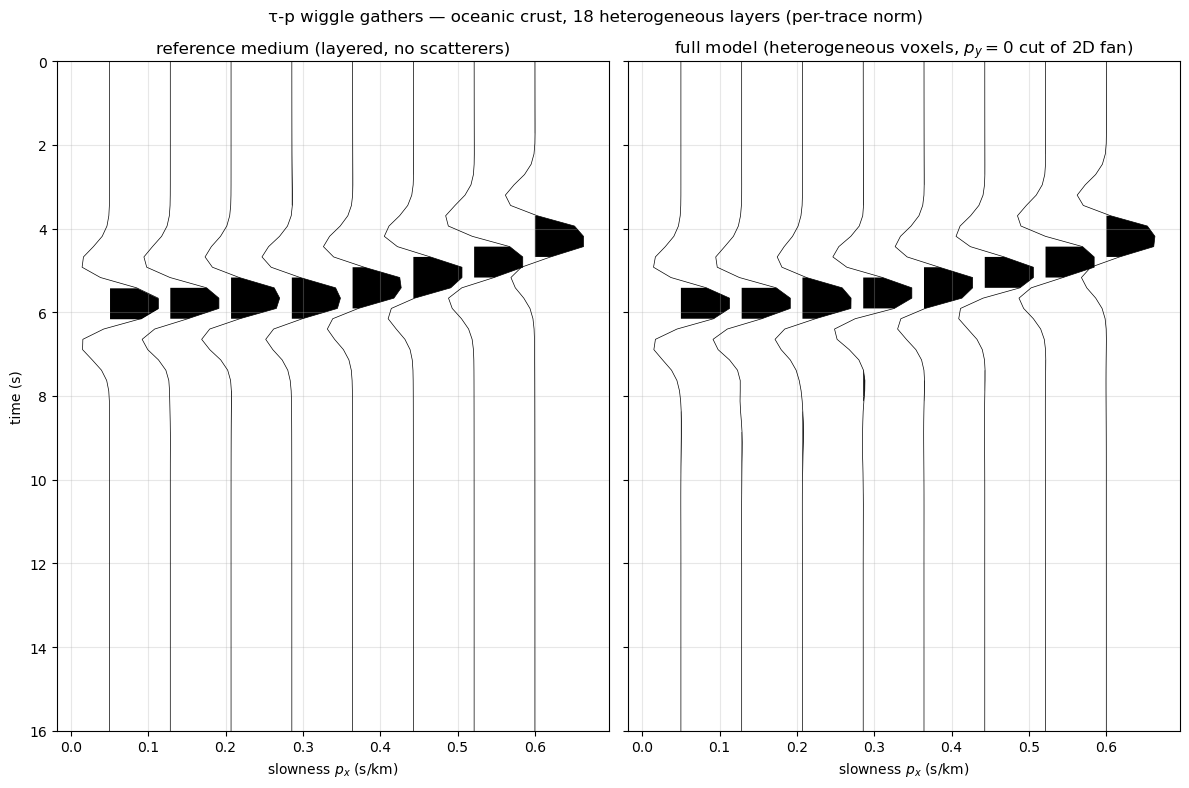

In [8]:
t_max = 16.0  # seconds shown
tmask = time_axis <= t_max
t_plot = time_axis[tmask]

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)


def _wiggle(ax, traces_2d, title):
    """Per-trace normalised variable-area wiggle plot.

    Because the heterogeneous gather has strong scattering poles that
    dominate a global peak normalisation, every trace is scaled by its
    own peak so low- and high-slowness events remain visible.
    """
    tr = traces_2d[tmask, :]
    peaks = np.abs(tr).max(axis=0).astype(np.float64)
    peaks[peaks == 0.0] = 1.0
    dp = float(p_values[1] - p_values[0]) if len(p_values) > 1 else 0.1
    for j, p in enumerate(p_values):
        sig = np.clip(tr[:, j] / peaks[j], -0.8, 0.8)
        ax.plot(p + dp * sig, t_plot, "k-", linewidth=0.5)
        ax.fill_betweenx(
            t_plot, p, p + dp * sig, where=(sig > 0), color="k", linewidth=0.0
        )
    ax.set_xlabel("slowness $p_x$ (s/km)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


_wiggle(axes[0], traces_ref, "reference medium (layered, no scatterers)")
_wiggle(
    axes[1],
    traces_total,
    "full model (heterogeneous voxels, $p_y=0$ cut of 2D fan)",
)
axes[0].set_ylabel("time (s)")
axes[0].set_ylim(t_plot.max(), t_plot.min())
fig.suptitle(
    "τ-p wiggle gathers — oceanic crust, 18 heterogeneous layers (per-trace norm)"
)
fig.tight_layout()
plt.show()

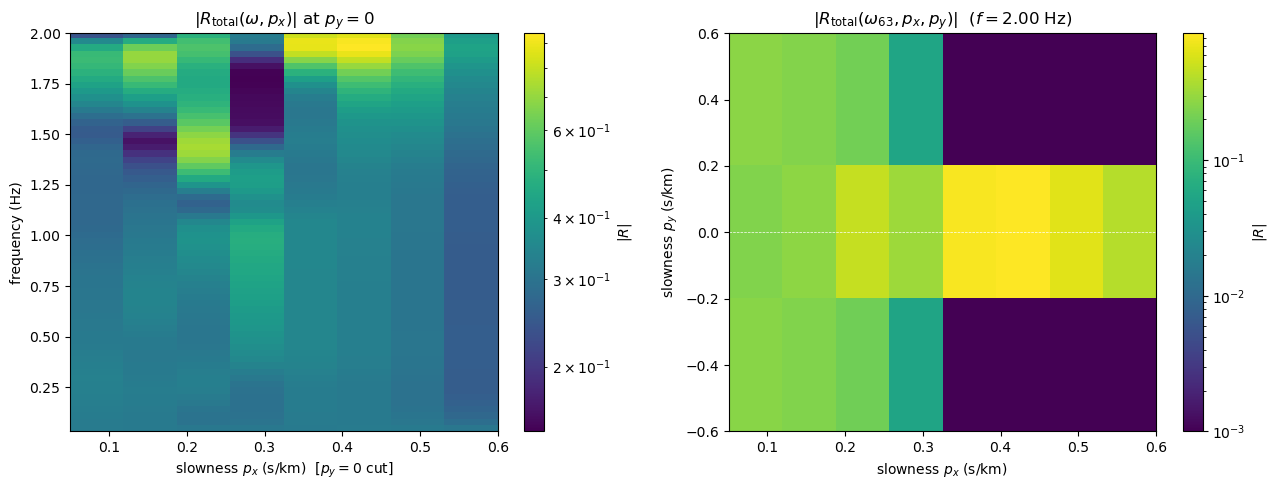

In [9]:
import matplotlib.colors as mcolors

# Left: |R_total(ω, p_x)| at p_y=0 (back-azimuthal cut)
amplitude_py0 = np.abs(R_total_py0)
vmax_py0 = float(amplitude_py0.max())
vmin_py0 = max(1.0e-3, float(amplitude_py0[amplitude_py0 > 0].min()))
if vmax_py0 <= vmin_py0:
    vmax_py0 = vmin_py0 * 10.0
norm_py0 = mcolors.LogNorm(vmin=vmin_py0, vmax=vmax_py0)

# Right: |R_total(ω_max, p_x, p_y)| 2D fan at the highest frequency.
# This is where horizontal scattering from the y direction shows up
# most clearly in the demo: the off-axis (p_y ≠ 0) columns carry the
# side-scattered modes that the strict ky=0 single-azimuth gather
# cannot see.
f_idx_show = config.nw - 1
amplitude_fan = np.abs(R_total_grid[f_idx_show])  # (n_p_x, n_p_y)
vmax_fan = float(amplitude_fan.max())
vmin_fan = max(1.0e-3, float(amplitude_fan[amplitude_fan > 0].min()))
if vmax_fan <= vmin_fan:
    vmax_fan = vmin_fan * 10.0
norm_fan = mcolors.LogNorm(vmin=vmin_fan, vmax=vmax_fan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(
    np.maximum(amplitude_py0, vmin_py0),
    aspect="auto",
    origin="lower",
    extent=(
        float(p_x_vals.min()),
        float(p_x_vals.max()),
        float(freqs_hz.min()),
        float(freqs_hz.max()),
    ),
    cmap="viridis",
    norm=norm_py0,
)
axes[0].set_xlabel("slowness $p_x$ (s/km)  [$p_y = 0$ cut]")
axes[0].set_ylabel("frequency (Hz)")
axes[0].set_title(r"$|R_{\mathrm{total}}(\omega, p_x)|$ at $p_y = 0$")
fig.colorbar(im0, ax=axes[0], label=r"$|R|$")

im1 = axes[1].imshow(
    np.maximum(amplitude_fan, vmin_fan).T,  # transpose so p_y is on the y-axis
    aspect="auto",
    origin="lower",
    extent=(
        float(p_x_vals.min()),
        float(p_x_vals.max()),
        float(p_y_vals.min()),
        float(p_y_vals.max()),
    ),
    cmap="viridis",
    norm=norm_fan,
)
axes[1].set_xlabel("slowness $p_x$ (s/km)")
axes[1].set_ylabel("slowness $p_y$ (s/km)")
axes[1].set_title(
    rf"$|R_{{\mathrm{{total}}}}(\omega_{{{f_idx_show}}}, p_x, p_y)|$"
    f"  ($f = {freqs_hz[f_idx_show]:.2f}$ Hz)"
)
axes[1].axhline(0.0, color="white", linewidth=0.5, linestyle="--")
fig.colorbar(im1, ax=axes[1], label=r"$|R|$")

fig.tight_layout()
plt.show()

## 7. Save Outputs (NPZ + PDFs)


In [10]:
output_dir = project_root / config.output_dir
output_dir.mkdir(parents=True, exist_ok=True)

# Pack layer_contrasts as a structured object array so downstream code
# can recover Δλ, Δμ, Δρ per voxel per iface.
layer_contrasts_serialised: dict[str, np.ndarray] = {}
for iface, cs in voxel_contrasts.items():
    arr = np.array([[c.Dlambda, c.Dmu, c.Drho] for c in cs], dtype=np.float64)
    layer_contrasts_serialised[f"iface_{iface:02d}"] = arr

npz_path = output_dir / config.npz_name
np.savez_compressed(
    npz_path,
    omegas_real=omegas_real,
    omegas_complex=omegas_complex,
    p_x_vals=p_x_vals,
    p_y_vals=p_y_vals,
    p_values=p_values,  # alias for p_x_vals (1D wiggle-gather axis)
    slowness_2d=slowness_2d,
    R_total_wp=R_total_wp,
    R_ref_wp=R_ref_wp,
    R_total_grid=R_total_grid,
    R_ref_grid=R_ref_grid,
    R_total_py0=R_total_py0,
    R_ref_py0=R_ref_py0,
    time=time_axis,
    traces_total=traces_total,
    traces_ref=traces_ref,
    rng_seed=np.int64(config.random_seed),
    config_yaml_raw=np.array(config.raw_yaml),
    **layer_contrasts_serialised,
)
print(f"NPZ saved to {npz_path}  ({npz_path.stat().st_size / 1e6:.2f} MB)")

plot_taup_wiggle_gather(
    time=time_axis,
    traces=traces_ref,
    p_values=p_values,
    title="Reference medium (no scatterers) — τ-p wiggle gather ($p_y=0$)",
    output=output_dir / config.fig_wiggle_reference,
    t_max=t_max,
)
plot_taup_wiggle_gather(
    time=time_axis,
    traces=traces_total,
    p_values=p_values,
    title="Heterogeneous voxels — τ-p wiggle gather ($p_y=0$ cut of 2D fan)",
    output=output_dir / config.fig_wiggle_total,
    t_max=t_max,
)
plot_r_omega_p_heatmap(
    R_omega_p=R_total_py0,
    freqs_hz=freqs_hz,
    p_values=p_values,
    title=r"$|R_{\mathrm{total}}(\omega, p_x)|$ at $p_y=0$",
    output=output_dir / config.fig_r_omega_p,
)
print("saved figures:")
for name in (
    config.fig_wiggle_reference,
    config.fig_wiggle_total,
    config.fig_r_omega_p,
):
    p = output_dir / name
    print(f"  {p}  ({p.stat().st_size / 1e3:.1f} kB)")

NPZ saved to /Users/tod/Desktop/SeismicInversion/GlobalMatrix/output/taup_scale_demo/taup_scale_demo.npz  (0.17 MB)
saved figures:
  /Users/tod/Desktop/SeismicInversion/GlobalMatrix/output/taup_scale_demo/taup_reference_wiggle_gather.pdf  (24.5 kB)
  /Users/tod/Desktop/SeismicInversion/GlobalMatrix/output/taup_scale_demo/taup_wiggle_gather.pdf  (25.4 kB)
  /Users/tod/Desktop/SeismicInversion/GlobalMatrix/output/taup_scale_demo/r_omega_p_heatmap.pdf  (23.5 kB)
